# Plot saved LCC-modified cells

Run this **after `build_modified_cells.py`**. It reads only the saved `modified_cells.nc`; it does not compare surface datasets again or require `equilibrium.py`.

Produces a north-polar map (45–90°N by default), a global overview, and an optional map of maximum absolute PFT change. Orange cells are selected; unselected cells are transparent. The selection follows the builder's **PCT_NAT_PFT** criterion and does not include changes solely in LAI or canopy height.

Dependencies: `numpy`, `pandas`, `xarray`, `netCDF4`, `matplotlib`; `cartopy` for projected maps. Without Cartopy, the notebook uses longitude–latitude plots. Coastlines use Cartopy's local Natural Earth data if available; no automatic download is required.

## 1. Set the saved mask path

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.path import Path as MplPath
try:
    from IPython.display import display
except ImportError:
    display = print

MASK_FILE = Path('modified_cells.nc')  # Or an absolute path on Betzy.
OUTPUT_DIR = Path('modified_cells_maps')
MIN_LAT = 45.0
CENTRAL_LONGITUDE = 0.0
SAVE_FIGURES = True
PLOT_CHANGE_MAGNITUDE = True
TRANSPARENT = True

try:
    import cartopy
    import cartopy.crs as ccrs
    from cartopy.io import shapereader
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print('Cartopy unavailable: using longitude–latitude plots.')

if not 0 <= MIN_LAT < 90:
    raise ValueError('MIN_LAT must be between 0 and 90 degrees (exclusive of 90).')
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the cached mask and list selected cells
Indices in the table refer to the original saved grid. Coordinates are then sorted only for plotting. The full selected-cell CSV produced by the builder remains unchanged.

In [2]:
if not MASK_FILE.is_file():
    raise FileNotFoundError(f'{MASK_FILE.resolve()} not found. Run build_modified_cells.py first or edit MASK_FILE.')
with xr.open_dataset(MASK_FILE) as source:
    mask_ds = source.load()
if 'modified' not in mask_ds or set(mask_ds.modified.dims) != {'lat', 'lon'}:
    raise ValueError('Expected modified(lat, lon), as written by build_modified_cells.py.')
if mask_ds.lat.ndim != 1 or mask_ds.lon.ndim != 1:
    raise ValueError('Expected one-dimensional lat/lon coordinates.')
original = mask_ds.modified.transpose('lat', 'lon')
if not np.isin(original.values, [0, 1]).all():
    raise ValueError('The mask must contain only 0 and 1, with no missing values.')
lat_native, lon_native = mask_ds.lat.values, mask_ds.lon.values
if not np.isfinite(lat_native).all() or not np.isfinite(lon_native).all() or np.any(abs(lat_native) > 90):
    raise ValueError('Invalid latitude or longitude values.')
if len(np.unique(lat_native)) != len(lat_native) or len(np.unique(lon_native % 360)) != len(lon_native):
    raise ValueError('Duplicate coordinates, including a possible cyclic longitude endpoint.')

i, j = np.where(original.values == 1)
selected_cells = pd.DataFrame({'lat_index': i, 'lon_index': j, 'lat': lat_native[i],
                               'lon_360': lon_native[j] % 360, 'lon_180': (lon_native[j] + 180) % 360 - 180})
if 'max_pft_change_pp' in mask_ds:
    magnitude = mask_ds.max_pft_change_pp.transpose('lat', 'lon')
    selected_cells['max_pft_change_pp'] = magnitude.values[i, j]
print(f'Modified cells: {len(selected_cells):,} / {original.size:,}')
print(f'Modified cell centres north of {MIN_LAT:g}°N: {(selected_cells.lat >= MIN_LAT).sum():,}')
print('Saved selection definition:', mask_ds.attrs.get('definition', 'not recorded'))
print('Tolerance (percentage points):', mask_ds.attrs.get('tolerance_pp', 'not recorded'))
print('Baseline:', mask_ds.attrs.get('baseline', 'not recorded'))
print('Modified surface:', mask_ds.attrs.get('modified_source', 'not recorded'))
display(selected_cells.head(20))

plot_ds = mask_ds.assign_coords(lon=(mask_ds.lon + 180) % 360 - 180).sortby('lon').sortby('lat')
changed = plot_ds.modified.transpose('lat', 'lon').astype(bool)
lat, lon = plot_ds.lat.values, plot_ds.lon.values

# Infer cell boundaries from rectilinear centres; this is a display convention.
# No new cell selection or surface-file comparison is performed.
def centre_edges(values, latitude=False):
    values = np.asarray(values, dtype=float)
    if len(values) < 2 or not np.all(np.diff(values) > 0):
        raise ValueError('At least two increasing coordinate centres are needed.')
    edges = np.r_[values[0] - (values[1] - values[0]) / 2,
                  (values[:-1] + values[1:]) / 2,
                  values[-1] + (values[-1] - values[-2]) / 2]
    return np.clip(edges, -90, 90) if latitude else edges

lat_edges, lon_edges = centre_edges(lat, True), centre_edges(lon)
# Wrap the last/first column into the opposite map edge for seamless global plotting.
# Require a regular global longitude grid for this wrap; otherwise plot its native extent.
cyclic = np.allclose(np.diff(np.r_[lon, lon[0] + 360]), 360 / len(lon), rtol=0, atol=1e-4)
if cyclic:
    step = 360 / len(lon)
    map_lon_edges = np.r_[lon_edges[0] - step, lon_edges, lon_edges[-1] + step]
else:
    map_lon_edges = lon_edges

def plot_values(field):
    values = np.asarray(field, dtype=float)
    return np.ma.masked_invalid(np.c_[values[:, -1], values, values[:, 0]] if cyclic else values)

Modified cells: 1,161 / 13,824
Modified cell centres north of 45°N: 1,161
Saved selection definition: any natural PFT absolute change > tolerance_pp
Tolerance (percentage points): 1e-06
Baseline: /cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/release-clm5.0.18/surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc
Modified surface: /cluster/shared/noresm/inputdata/lnd/clm2/surfdata_map/surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc


,lat_index,lon_index,lat,lon_360,lon_180,max_pft_change_pp
0,72,55,46.421053,137.5,137.5,13.208914
1,72,57,46.421053,142.5,142.5,11.640597
2,72,60,46.421053,150.0,150.0,7.500000
3,72,122,46.421053,305.0,-55.0,2.853672
4,72,123,46.421053,307.5,-52.5,0.811837
5,73,43,48.315789,107.5,107.5,28.266342
6,73,44,48.315789,110.0,110.0,17.357013
7,73,55,48.315789,137.5,137.5,13.931063
8,73,56,48.315789,140.0,140.0,9.247258
9,73,57,48.315789,142.5,142.5,11.271527


## 3. Plot functions
The coastline layer is optional and uses locally cached data only. Cell counts use cell centres; cell polygons can cross the 45°N display boundary.

In [3]:
def add_local_coastlines(ax):
    if not HAS_CARTOPY:
        return
    relative = Path('shapefiles/natural_earth/physical/ne_110m_coastline.shp')
    for key in ('pre_existing_data_dir', 'data_dir'):
        location = Path(cartopy.config[key]) / relative
        if location.is_file():
            reader = shapereader.Reader(str(location))
            try:
                ax.add_geometries(list(reader.geometries()), ccrs.PlateCarree(), facecolor='none', edgecolor='0.3', linewidth=.55)
            finally:
                reader.close()
            return
    print('No cached Natural Earth coastlines: plotting cells and graticule only.')


def map_axes(polar=True):
    if HAS_CARTOPY:
        projection = ccrs.Orthographic(CENTRAL_LONGITUDE, 90) if polar else ccrs.PlateCarree()
        fig, ax = plt.subplots(figsize=(7, 7) if polar else (12, 5), subplot_kw={'projection': projection}, layout='constrained')
        if polar:
            # Orthographic radius at the requested parallel; circular crop excludes lower latitudes.
            radius = float(projection.transform_point(CENTRAL_LONGITUDE + 90, MIN_LAT, ccrs.PlateCarree())[0])
            ax.set_xlim(-radius, radius)
            ax.set_ylim(-radius, radius)
            theta = np.linspace(0, 2 * np.pi, 361)
            boundary = MplPath(np.c_[np.sin(theta), np.cos(theta)] * .5 + .5)
            ax.set_boundary(boundary, transform=ax.transAxes)
        else:
            ax.set_global()
        add_local_coastlines(ax)
        ax.gridlines(linewidth=.45, color='0.5', alpha=.45, linestyle=':')
    else:
        fig, ax = plt.subplots(figsize=(12, 4.5), layout='constrained')
        ax.set(xlim=(-180, 180), ylim=(MIN_LAT if polar else -90, 90), xlabel='Longitude (°)', ylabel='Latitude (°)')
        ax.grid(alpha=.2)
    return fig, ax


def draw_cells(ax, field, **kwargs):
    transform = {'transform': ccrs.PlateCarree()} if HAS_CARTOPY else {}
    return ax.pcolormesh(map_lon_edges, lat_edges, plot_values(field), shading='flat', rasterized=True, **transform, **kwargs)


def save_figure(fig, name):
    if SAVE_FIGURES:
        for extension in ('png', 'pdf'):
            file = OUTPUT_DIR / f'{name}.{extension}'
            fig.savefig(file, dpi=220, transparent=TRANSPARENT, bbox_inches='tight')
            print('Saved:', file)

## 4. Modified cells: north-polar map

Saved: modified_cells_maps/modified_cells_north.png
Saved: modified_cells_maps/modified_cells_north.pdf


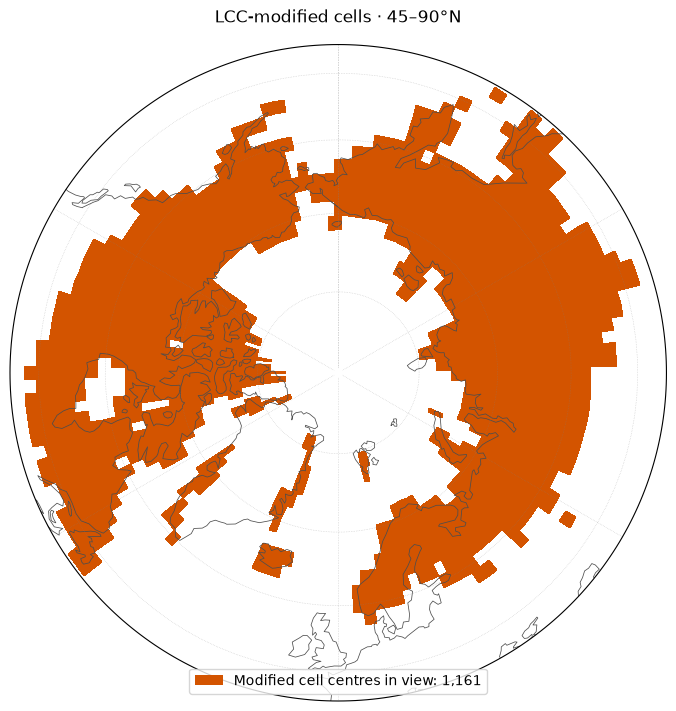

In [4]:
highlight = np.where(changed.values, 1.0, np.nan)
fig, ax = map_axes(polar=True)
draw_cells(ax, highlight, cmap=ListedColormap(['#D35400']), vmin=.5, vmax=1.5)
north_count = int(selected_cells.lat.ge(MIN_LAT).sum())
ax.set_title(f'LCC-modified cells · {MIN_LAT:g}–90°N', pad=16)
ax.legend(handles=[Patch(facecolor='#D35400', label=f'Modified cell centres in view: {north_count:,}')], loc='lower center', frameon=True)
if not north_count:
    print('No selected cell centres in this latitude range.')
save_figure(fig, 'modified_cells_north')
plt.show()

## 5. Global overview
Use this to detect selected cells outside the intended northern domain.

Saved: modified_cells_maps/modified_cells_global.png
Saved: modified_cells_maps/modified_cells_global.pdf


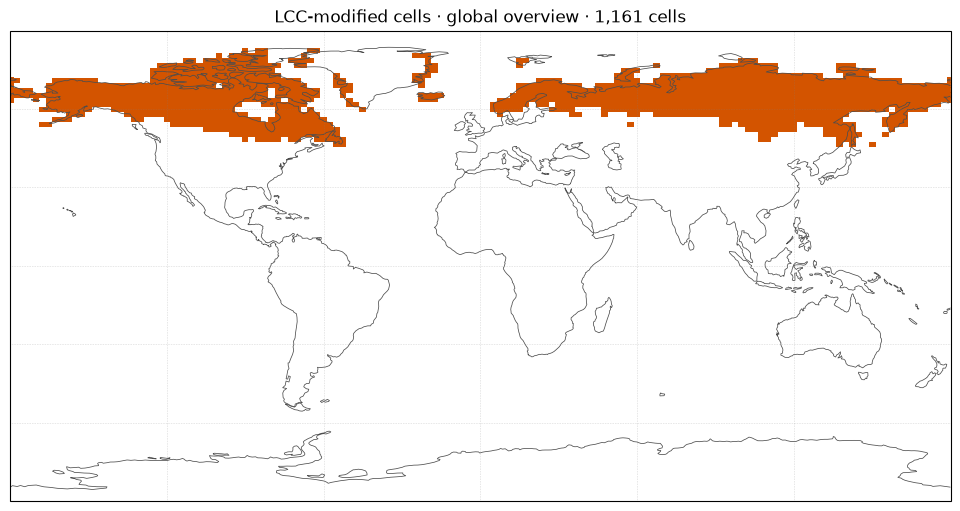

In [5]:
fig, ax = map_axes(polar=False)
draw_cells(ax, highlight, cmap=ListedColormap(['#D35400']), vmin=.5, vmax=1.5)
ax.set_title(f'LCC-modified cells · global overview · {len(selected_cells):,} cells')
save_figure(fig, 'modified_cells_global')
plt.show()

## 6. Optional: magnitude of the saved PFT change
This is the **largest absolute change among natural PFT fractions in each cell**, in percentage points. It is neither net forest expansion nor a relative percentage change; gains and losses both contribute to this magnitude.

Saved: modified_cells_maps/modified_cells_pft_change.png
Saved: modified_cells_maps/modified_cells_pft_change.pdf


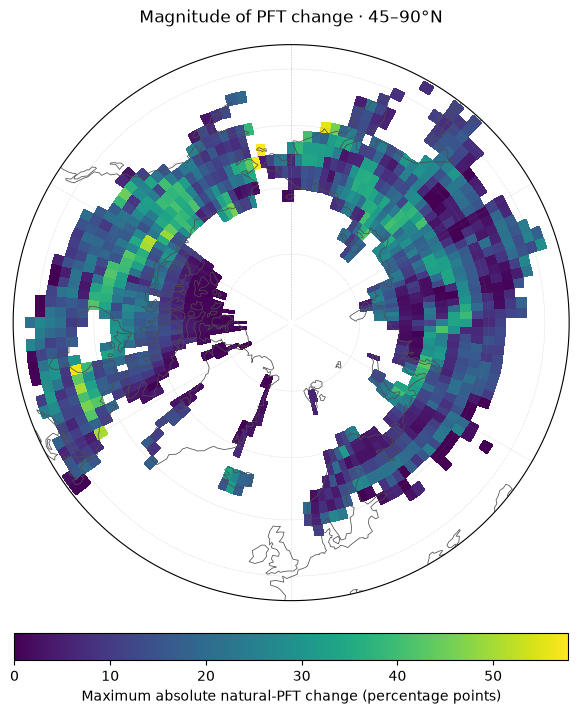

In [6]:
if PLOT_CHANGE_MAGNITUDE and 'max_pft_change_pp' in plot_ds:
    delta = plot_ds.max_pft_change_pp.transpose('lat', 'lon').where(changed)
    finite = delta.where(plot_ds.lat >= MIN_LAT).values
    finite = finite[np.isfinite(finite)]
    if finite.size:
        fig, ax = map_axes(polar=True)
        mesh = draw_cells(ax, delta.values, cmap='viridis', vmin=0, vmax=max(float(finite.max()), 1e-12))
        fig.colorbar(mesh, ax=ax, orientation='horizontal', pad=.05, shrink=.8,
                     label='Maximum absolute natural-PFT change (percentage points)')
        ax.set_title(f'Magnitude of PFT change · {MIN_LAT:g}–90°N', pad=16)
        save_figure(fig, 'modified_cells_pft_change')
        plt.show()
    else:
        print('No finite selected-cell changes in this latitude range.')
elif PLOT_CHANGE_MAGNITUDE:
    print('No max_pft_change_pp field in this cached file; mask plots remain available.')

## Notes

- Change `MASK_FILE` to the `.nc` file written by your builder. The accompanying CSV is not needed to plot.
- Both PNG and PDF files are saved when `SAVE_FIGURES=True`; use `TRANSPARENT=False` for a white background.
- Cell edges are inferred from coordinate centres; selections and stored change magnitudes are unchanged.
- Validation used a synthetic mask; your actual Betzy mask was unavailable. Notebook code is checked in sequence in plain Python; run all cells in your Jupyter environment to verify the real map.